✓ Dataset 'day.csv' berhasil dimuat!

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

=== RUNNING: DESCRIPTIV

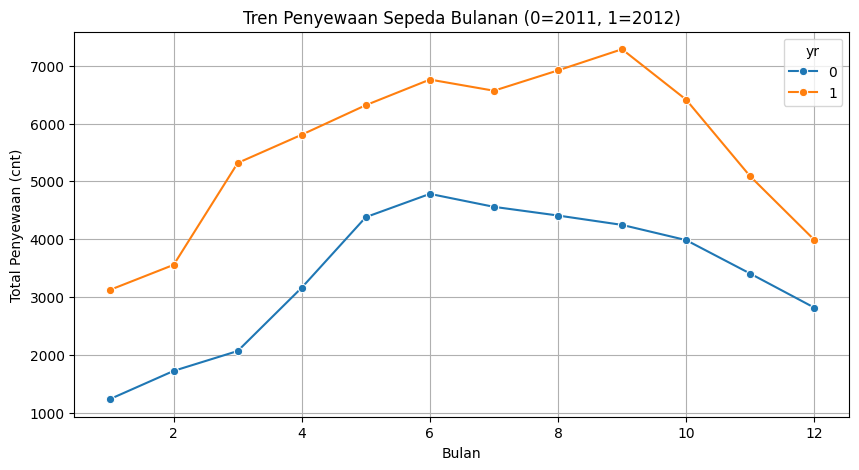

✓ Grafik tren bulanan disimpan sebagai 'descriptive.png'

=== RUNNING: DIAGNOSTIC ANALYTICS ===


/tmp/ipykernel_1286/140754413.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='weathersit', y='cnt', palette='muted')


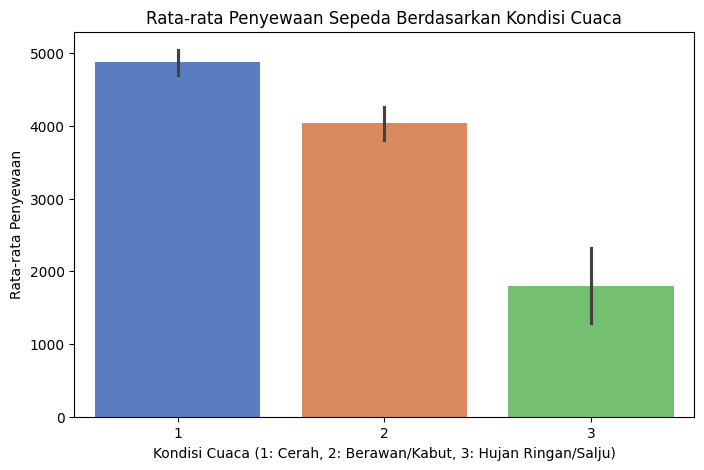

✓ Grafik analisis cuaca disimpan sebagai 'diagnostic.png'

=== RUNNING: CLUSTERING ===


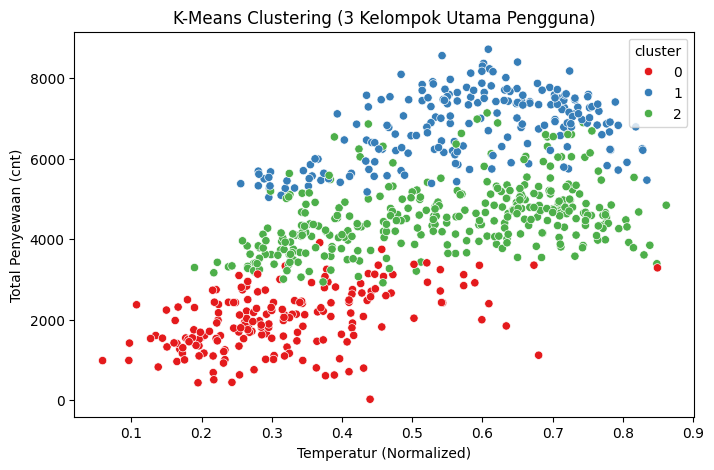

✓ Grafik pengelompokan disimpan sebagai 'clustering.png'

=== RUNNING: PREDICTIVE ANALYTICS ===


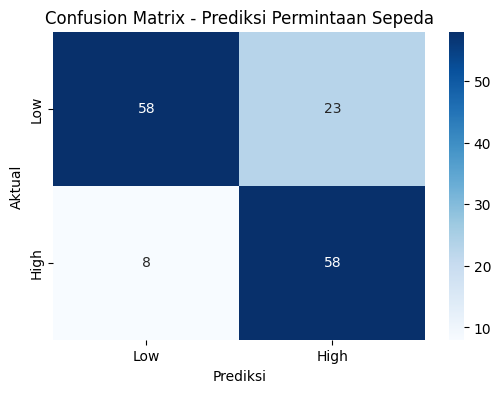

Akurasi Model Prediksi: 78.91%
✓ Grafik Confusion Matrix disimpan sebagai 'confusion_matrix.png'


In [1]:
# ==========================================
# SECTION 1 & 2: IMPORT LIBRARIES & LOAD DATA
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Mengunduh dataset langsung dari GitHub atau mengunggah secara lokal
# Untuk kemudahan di Colab, kita akan memuat file data kamu langsung.
# (Pastikan kamu mengunggah file day.csv ke panel file di sebelah kiri Colab dengan nama 'day.csv')
try:
    df = pd.read_csv('day.csv')
    print("✓ Dataset 'day.csv' berhasil dimuat!")
except FileNotFoundError:
    # Backup jika file belum diganti namanya
    try:
        df = pd.read_csv('1782084533494_day 2.csv')
        print("✓ Dataset '1782084533494_day 2.csv' berhasil dimuat!")
    except:
        print("⚠ File tidak ditemukan. Tolong upload file dataset kamu ke Google Colab di panel sebelah kiri dan namai 'day.csv'")

# ==========================================
# SECTION 3 & 4: DATA UNDERSTANDING & PREPARATION
# ==========================================
print("\n=== INFORMASI DATASET ===")
print(df.info())

# ==========================================
# SECTION 5: DESCRIPTIVE ANALYTICS
# ==========================================
print("\n=== RUNNING: DESCRIPTIVE ANALYTICS ===")
# 1. Tren bulanan penyewaan sepeda
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='mnth', y='cnt', hue='yr', marker='o', errorbar=None)
plt.title('Tren Penyewaan Sepeda Bulanan (0=2011, 1=2012)')
plt.xlabel('Bulan')
plt.ylabel('Total Penyewaan (cnt)')
plt.grid(True)
plt.savefig('descriptive.png')
plt.show()
print("✓ Grafik tren bulanan disimpan sebagai 'descriptive.png'")

# ==========================================
# SECTION 6: DIAGNOSTIC ANALYTICS
# ==========================================
print("\n=== RUNNING: DIAGNOSTIC ANALYTICS ===")
# Pengaruh cuaca (weathersit) terhadap jumlah penyewaan
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='weathersit', y='cnt', palette='muted')
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca (1: Cerah, 2: Berawan/Kabut, 3: Hujan Ringan/Salju)')
plt.ylabel('Rata-rata Penyewaan')
plt.savefig('diagnostic.png')
plt.show()
print("✓ Grafik analisis cuaca disimpan sebagai 'diagnostic.png'")

# ==========================================
# SECTION 7: CLUSTERING & HIDDEN PATTERN
# ==========================================
print("\n=== RUNNING: CLUSTERING ===")
X_clust = df[['temp', 'hum', 'windspeed', 'casual', 'registered']]
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_clust)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='temp', y='cnt', hue='cluster', palette='Set1')
plt.title('K-Means Clustering (3 Kelompok Utama Pengguna)')
plt.xlabel('Temperatur (Normalized)')
plt.ylabel('Total Penyewaan (cnt)')
plt.savefig('clustering.png')
plt.show()
print("✓ Grafik pengelompokan disimpan sebagai 'clustering.png'")

# ==========================================
# SECTION 8: PREDICTIVE ANALYTICS
# ==========================================
print("\n=== RUNNING: PREDICTIVE ANALYTICS ===")
# Menentukan target: High Demand (1) jika di atas nilai median, Low Demand (0) jika di bawah median
median_cnt = df['cnt'].median()
df['demand_target'] = (df['cnt'] >= median_cnt).astype(int)

X_pred = df[['season', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed']]
y_pred = df['demand_target']

X_train, X_test, y_train, y_test = train_test_split(X_pred, y_pred, test_size=0.2, random_state=42)
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
y_pred_test = dt.predict(X_test)

# Grafik Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.title('Confusion Matrix - Prediksi Permintaan Sepeda')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.savefig('confusion_matrix.png')
plt.show()

print(f"Akurasi Model Prediksi: {accuracy_score(y_test, y_pred_test) * 100:.2f}%")
print("✓ Grafik Confusion Matrix disimpan sebagai 'confusion_matrix.png'")